**inisialisasi library**

In [1]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

**1. Struktur Data Graf dan Algoritma**

In [15]:
def dijkastra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    prev = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                prev[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, prev

**2. Fungsi untuk Merekonstruksi Jalur**

In [11]:
def get_path(prev, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = prev[target]
    return path

**3. Visualisasi dengan Networkx dan Matplotlib**

In [12]:
def visualisasi_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)
    
    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

**4. Pengaplikasian**

In [13]:
# Definisi graf
graph = {
    'A' : {'B' : 4, 'C' : 2},
    'B' : {'C' : 1, 'D' : 5},
    'C' : {'D' : 8, 'E' : 10},
    'D' : {'E' : 2, 'Z' : 6},
    'E' : {'Z' : 3},
    'Z' : {}
}

In [16]:
# Menjalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distance, prev = dijkastra_with_paths(graph, start_node)

In [17]:
# Rekonstruksi jalur
jalur_terpendek = get_path(prev, end_node)
print(f"""Jarak dari {start_node} ke {end_node} : {distance[end_node]}
Jalur: {'->'.join(jalur_terpendek)}
""")

Jarak dari A ke Z : 14
Jalur: A->B->D->E->Z



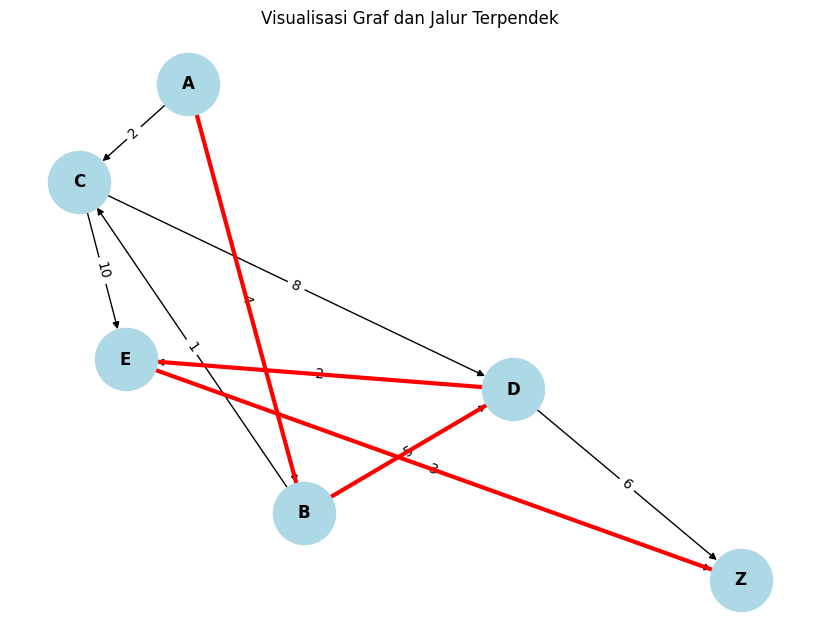

In [18]:
visualisasi_graph(graph, path=jalur_terpendek)